### Assignment 1

**Name:** Balasooriya BRBD  
**Index Number:** 230070T  
**GitHub Link:** [Link](https://github.com/banula33/VISION-ASSIGNEMNT)  


### Question 1: Piecewise Linear Intensity Transformation

In this task, we implement a piecewise linear intensity transformation based on provided breakpoints.

1. **Given Breakpoints:** Using the requested breakpoints `[[0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]]`, the transformation increases the contrast and brightness for the mid-tones and highlights, resulting in a noticeably brighter image.
2. **Experimental Breakpoints:** To create a more visually pleasing output, I experimented with custom breakpoints `[[0, 0],
    [50, 75],
    [150, 200],
    [255, 255]]`. This creates a subtle "S-curve" that slightly darkens shadows and boosts mid-tone contrast, resulting in a more dramatic and aesthetically pleasing portrait without blowing out the highlights.


Results using the breakpoints provided in the question:


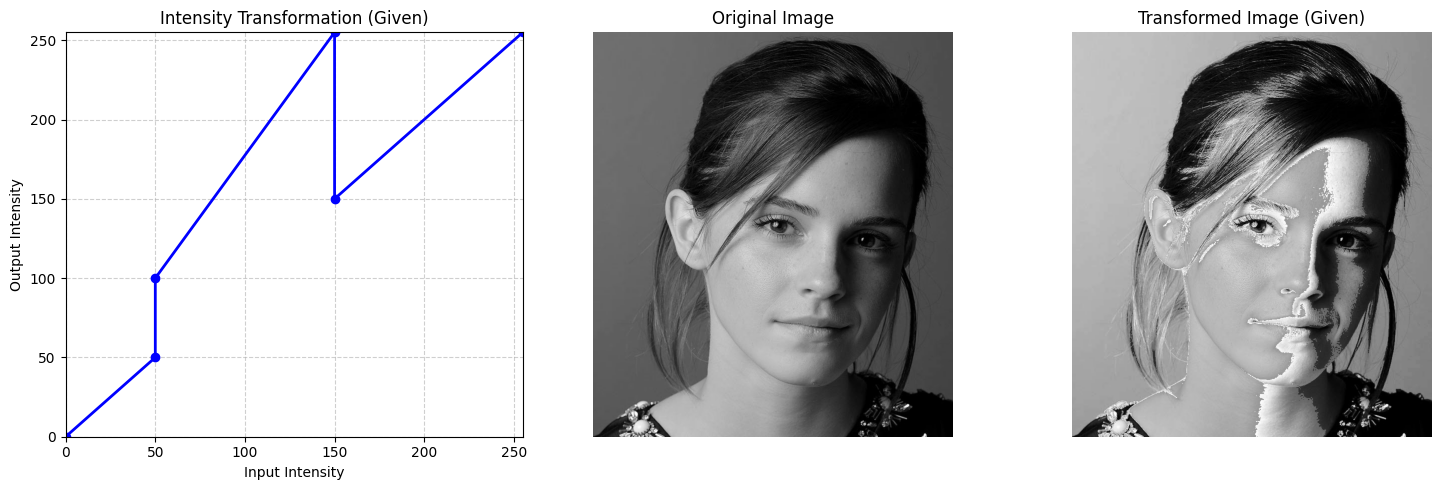

Results using custom breakpoints for a visually pleasing output:


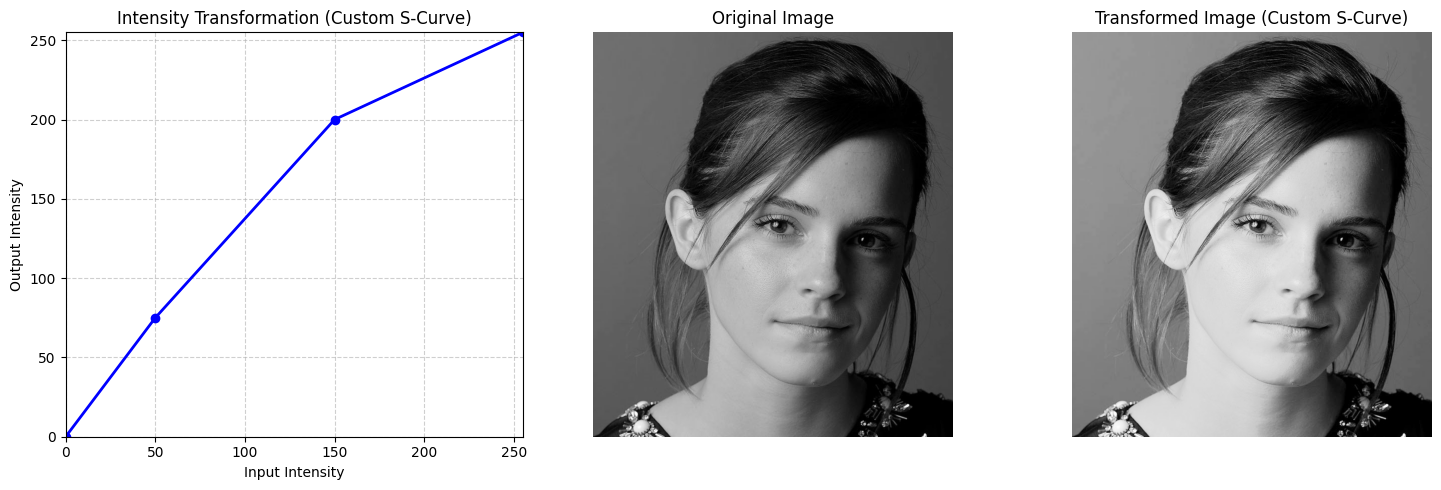

In [58]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    
    lut = np.zeros(256, dtype=np.uint8)
    
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i+1]
        
        if x2 - x1 != 0:
            m = (y2 - y1) / (x2 - x1)
        else:
            m = 0
            
        c = y1 - m * x1
        
        for x in range(x1, x2 + 1):
            if x < 256:
                val = m * x + c
                lut[x] = np.clip(val, 0, 255)
                
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im
img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q1.jpeg'

original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


breakpoints_given = [
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
]

transformed_image_given = intensity_transform(original_image, breakpoints_given)

def plot_results(original, transformed, breakpoints, title_suffix=""):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='blue', linewidth=2)
    plt.title(f'Intensity Transformation {title_suffix}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Transformed Image {title_suffix}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Results using the breakpoints provided in the question:")
plot_results(original_image, transformed_image_given, breakpoints_given, "(Given)")

breakpoints_custom = [
    [0, 0],
    [50, 75],
    [150, 200],
    [255, 255]
]
transformed_image_custom = intensity_transform(original_image, breakpoints_custom)

print("Results using custom breakpoints for a visually pleasing output:")
plot_results(original_image, transformed_image_custom, breakpoints_custom, "(Custom S-Curve)")


## Question 2: Accentuation of Specific Tissues

To accentuate specific tissues in the brain proton density image, we use contrast stretching to assign a steep slope (high contrast) to the specific intensity range of the target tissue, while flattening the curve for everything else.

1. **(a) Accentuate White Matter:** White matter appears brighter in this image. To accentuate it, we define breakpoints that aggressively stretch the higher intensity band (e.g., steepening the curve between input intensities of roughly 150 to 220).
2. **(b) Accentuate Gray Matter:** Gray matter occupies the mid-tone intensity range. To accentuate it, we steepen the transformation curve in the middle of the histogram (e.g., from roughly 80 to 140), while flattening the curve for darker and lighter regions.


Accentuation of White Matter:


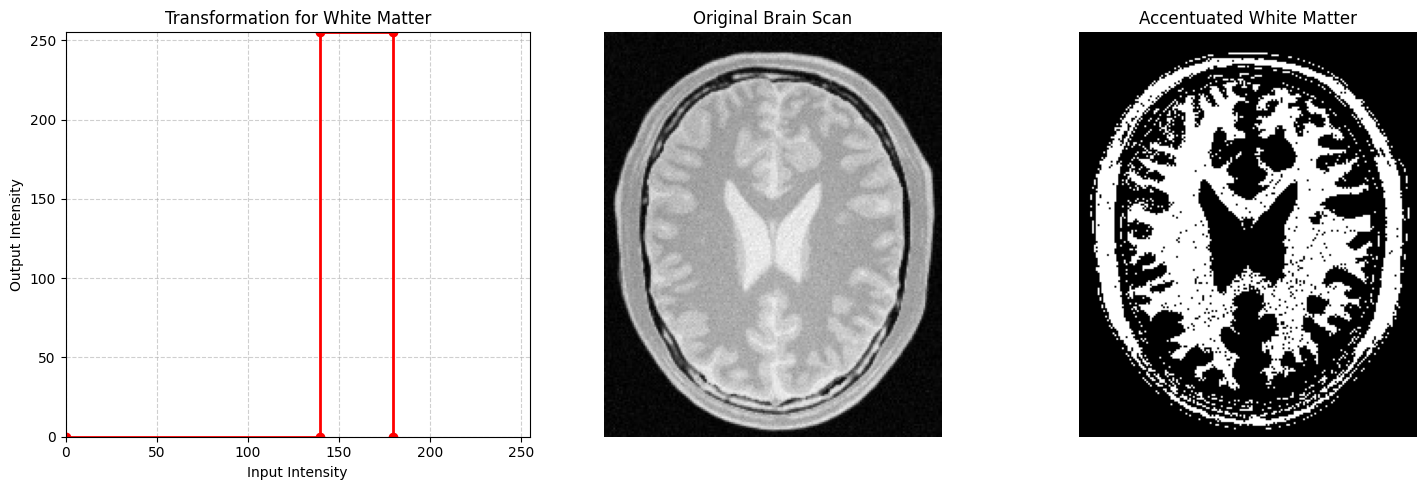

Accentuation of Gray Matter:


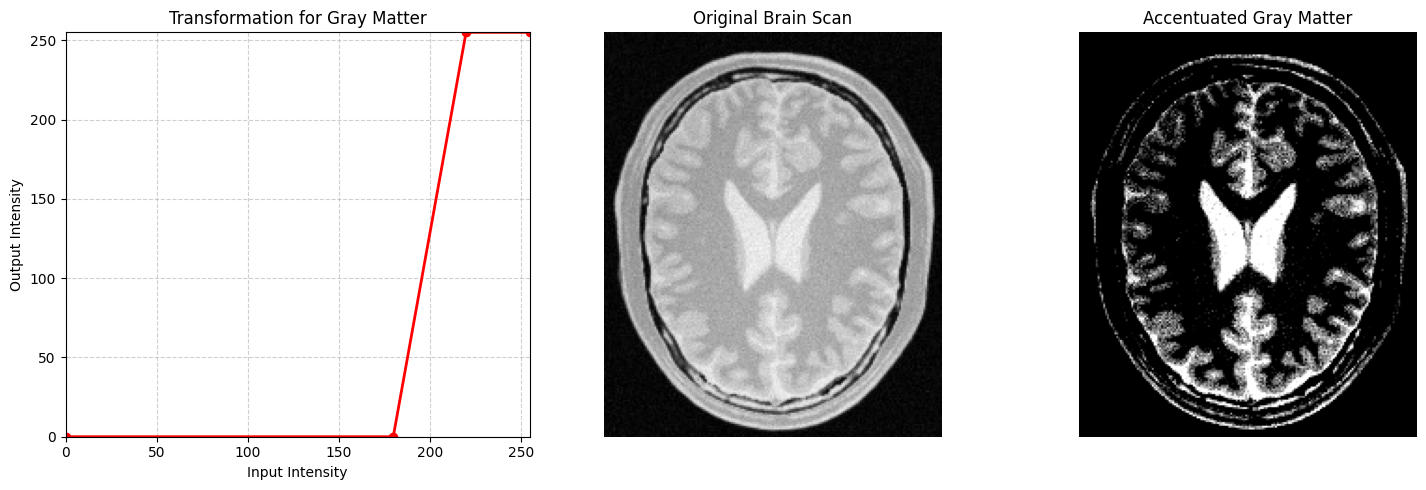

In [65]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q2.jpeg' 
brain_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    
breakpoints_wm = [
    [0, 0],
    [140, 0], 
    [140, 255],   
    [180, 255],  
    [180, 0]
]

accentuated_wm = intensity_transform(brain_image, breakpoints_wm)

breakpoints_gm = [
    [0, 0],
    [180, 0], 
    [220, 255],   
    [255, 255],  
]

accentuated_gm = intensity_transform(brain_image, breakpoints_gm)

def plot_accentuation(original, transformed, breakpoints, target_name):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Intensity Transformation Curve
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='red', linewidth=2)
    plt.title(f'Transformation for {target_name}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    # Plot 2: Original Image
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Brain Scan')
    plt.axis('off')
    
    # Plot 3: Transformed Image
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Accentuated {target_name}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display results
print("Accentuation of White Matter:")
plot_accentuation(brain_image, accentuated_wm, breakpoints_wm, "White Matter")

print("Accentuation of Gray Matter:")
plot_accentuation(brain_image, accentuated_gm, breakpoints_gm, "Gray Matter")


## Question 3: Gamma Correction in L\*a\*b\* Color Space

To adjust brightness without altering the image's color balance, we convert the image to the **CIE L\*a\*b\*** color space and apply gamma correction exclusively to the Lightness (L) plane.

1. **Gamma Value:** I applied a gamma value of **$\gamma = 0.5$**. Because $\gamma < 1$, this expands the dark regions, significantly brightening the underexposed rocks in the background to reveal texture, without completely washing out the bright white dress.
2. **Histograms:** The histogram of the original L plane has a heavy concentration of pixels clustered in the dark values. After applying $\gamma = 0.5$, the histogram shifts towards the mid-tones and highlights, confirming the shadow regions have been successfully brightened.


<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\3752337407.py:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.title(f'Gamma Corrected ($\gamma$ = {gamma})')


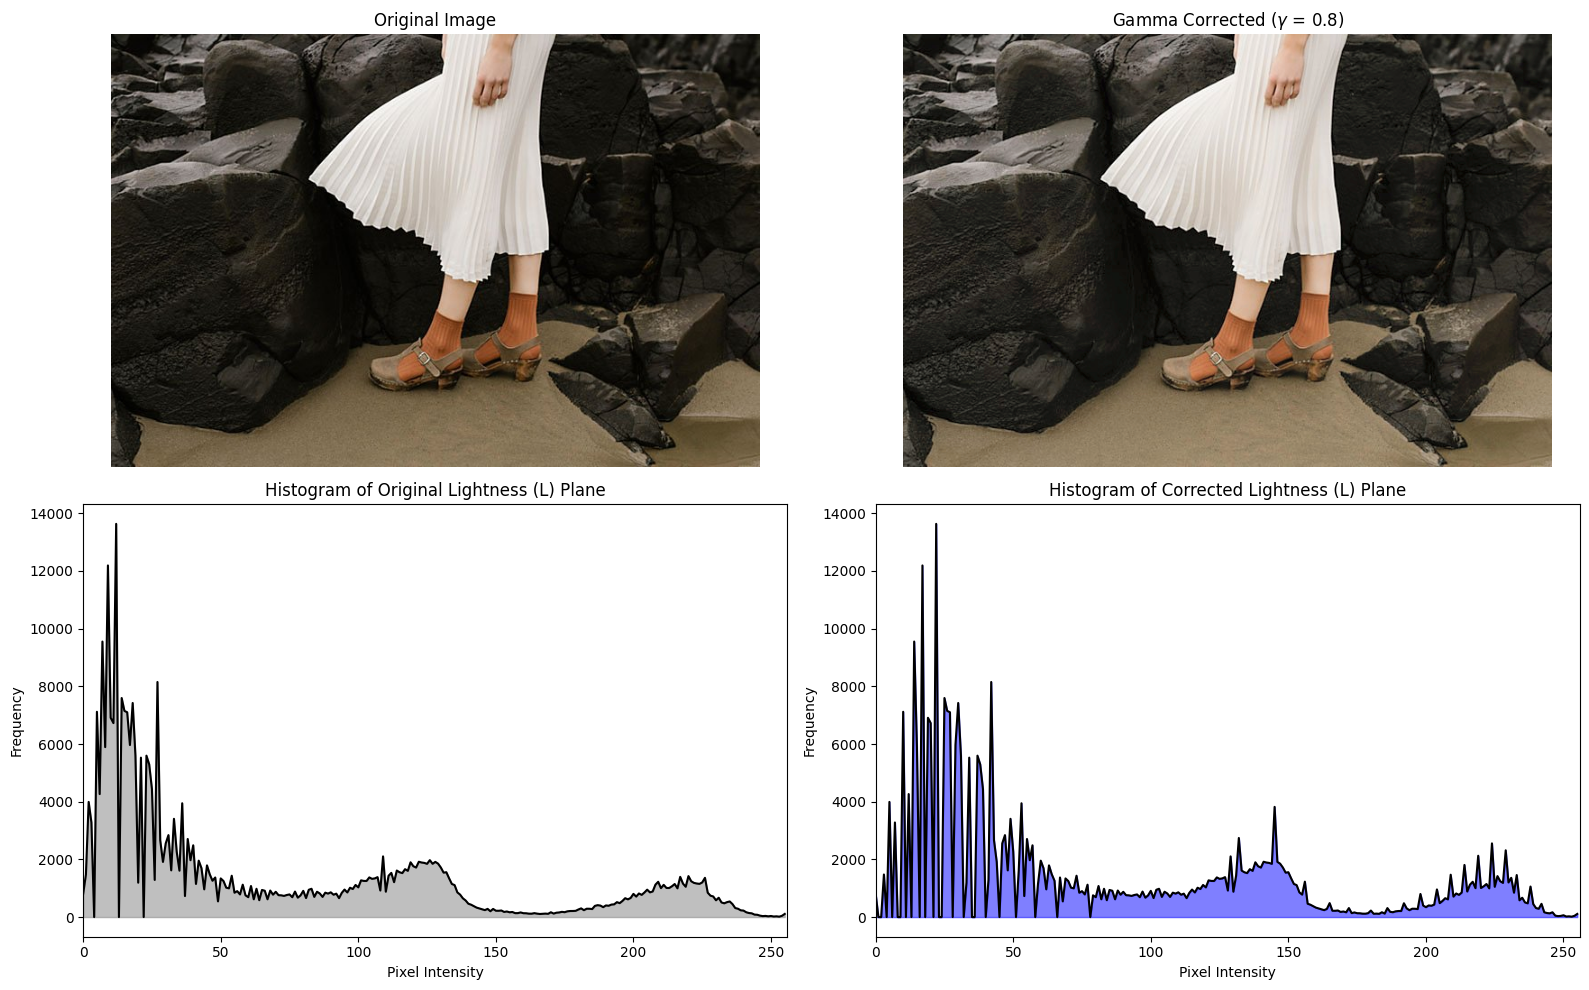

In [103]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q3.jpeg' 
img_bgr = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

gamma = 0.8

lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

L_corrected = cv2.LUT(L, lut)

img_lab_corrected = cv2.merge((L_corrected, a, b))
img_bgr_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
img_rgb_corrected = cv2.cvtColor(img_bgr_corrected, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_rgb_corrected)
plt.title(f'Gamma Corrected ($\gamma$ = {gamma})')
plt.axis('off')

plt.subplot(2, 2, 3)
hist_original = cv2.calcHist([L], [0], None, [256], [0, 256])
plt.plot(hist_original, color='black')
plt.fill_between(range(256), hist_original.flatten(), color='gray', alpha=0.5)
plt.title('Histogram of Original Lightness (L) Plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
hist_corrected = cv2.calcHist([L_corrected], [0], None, [256], [0, 256])
plt.plot(hist_corrected, color='black')
plt.fill_between(range(256), hist_corrected.flatten(), color='blue', alpha=0.5)
plt.title('Histogram of Corrected Lightness (L) Plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()


## Question 4: Increasing Vibrance via Intensity Transformation

To increase vibrance without altering hue or brightness, we convert the RGB image to the **HSV** color space and apply the non-linear intensity transformation exclusively to the Saturation (S) plane.

1. **Parameter Value:** Through experimentation, I found that **$a = 0.5$** yields a visually pleasing and balanced output. 
2. **Visual Effect:** The transformation uses a Gaussian curve to specifically boost mid-tone saturation values, while leaving already-saturated and grayscale areas mostly untouched. This prevents unnatural oversaturation. After recombining the H, S, and V planes, the colors in the resulting image appear noticeably more vivid and punchy.


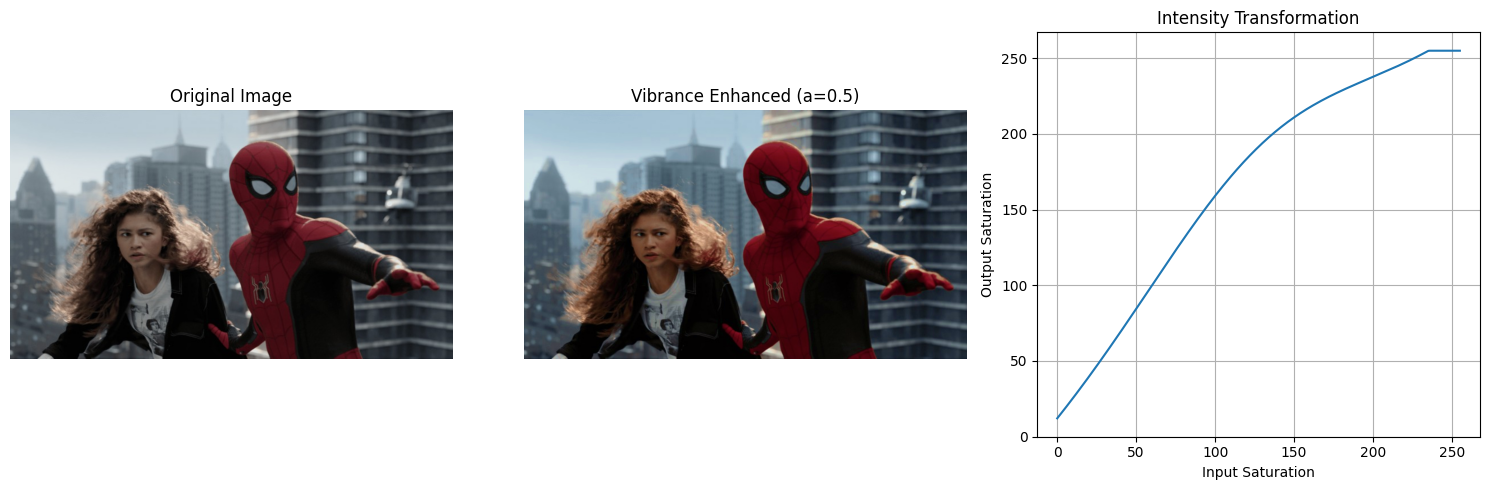

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/q4.jpeg') # Update filename if necessary
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

a = 0.5 
sigma = 70

s_float = s.astype(np.float32)
s_transformed = s_float + a * 128 * np.exp(-((s_float - 128)**2) / (2 * sigma**2))
s_transformed = np.clip(s_transformed, 0, 255).astype(np.uint8)

img_hsv_transformed = cv2.merge([h, s_transformed, v])
img_vibrance = cv2.cvtColor(img_hsv_transformed, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_vibrance)
axes[1].set_title(f'Vibrance Enhanced (a={a})')
axes[1].axis('off')

x = np.arange(0, 256)
y = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255)
axes[2].plot(x, y)
axes[2].set_title('Intensity Transformation')
axes[2].set_xlabel('Input Saturation')
axes[2].set_ylabel('Output Saturation')
axes[2].grid()

plt.tight_layout()
plt.show()


## Question 5: Custom Histogram Equalization

To improve global contrast, we implemented a custom histogram equalization function from scratch.

1. **Implementation:** The function calculates the image's histogram, computes the Cumulative Distribution Function (CDF), and normalizes it to the 0-255 range. This normalized CDF is then used as a lookup table to mathematically map original pixel intensities to their new, equalized values.
2. **Results:** The original image's histogram shows pixel intensities clustered tightly in a narrow, dark range. After applying our custom function, the histogram is effectively "stretched" out, distributing intensities much more broadly across the spectrum. This significantly enhances the global contrast, revealing details that were previously hidden in the dark, muddy areas.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\886581770.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0, 1].hist(img.flatten(), 256, [0, 256], color='blue')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\886581770.py:36: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(img_eq.flatten(), 256, [0, 256], color='red')


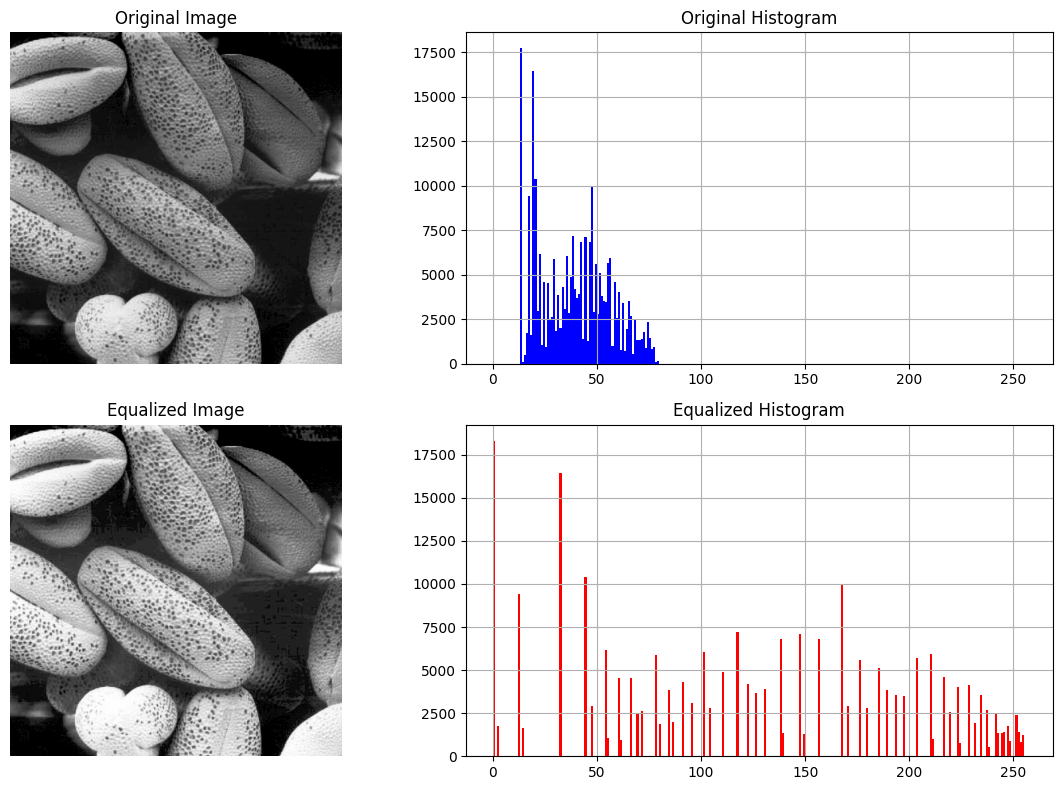

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_histogram_equalize(image):
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])
    
    cdf = hist.cumsum()
    
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_final = np.ma.filled(cdf_masked, 0).astype('uint8')
    
    img_equalized = cdf_final[image]
    return img_equalized

img = cv2.imread('images/q5.tif', cv2.IMREAD_GRAYSCALE)


img_eq = custom_histogram_equalize(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(img.flatten(), 256, [0, 256], color='blue')
axes[0, 1].set_title('Original Histogram')
axes[0, 1].grid()

axes[1, 0].imshow(img_eq, cmap='gray')
axes[1, 0].set_title('Equalized Image')
axes[1, 0].axis('off')

axes[1, 1].hist(img_eq.flatten(), 256, [0, 256], color='red')
axes[1, 1].set_title('Equalized Histogram')
axes[1, 1].grid()

plt.tight_layout()
plt.show()


## Question 6: Foreground-Only Histogram Equalization

To perform histogram equalization exclusively on the foreground, we process the image in the HSV color space.

1. **Foreground Mask Extraction:** Because the background is gray (desaturated) and the subject is colored, applying Otsu's thresholding to the Saturation (S) plane cleanly isolates the foreground into a binary mask.
2. **Targeted Equalization:** Using bitwise operations, we extract just the foreground of the Value (V) plane, compute its histogram, and calculate the normalized CDF. 
3. **Results:** We use this CDF to map and equalize *only* the foreground pixels. After adding the untouched background back in, we successfully enhanced the contrast and details of the subject without introducing noise or blowing out the flat background.


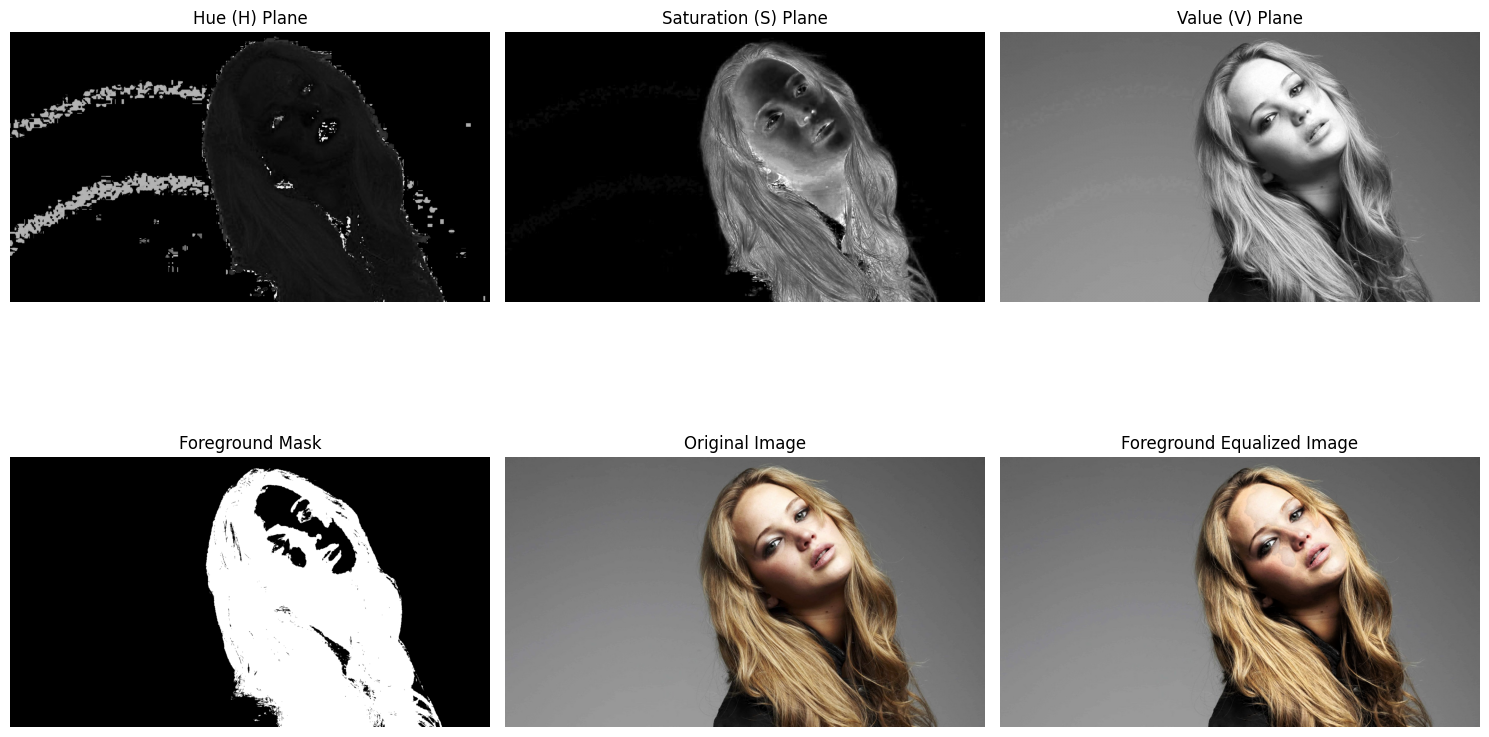

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/q6.jpeg') # Update filename if necessary
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# (a) Split into H, S, V planes
H, S, V = cv2.split(img_hsv)

# (b) Threshold the Saturation plane to extract foreground mask
_, mask = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# (c) Obtain foreground only and compute histogram
fg_only = cv2.bitwise_and(V, V, mask=mask)
hist = cv2.calcHist([fg_only], [0], mask, [256], [0, 256])

# (d) Obtain cumulative sum
cdf = hist.cumsum()

# (e) Histogram-equalize the foreground
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

V_eq_mapped = cdf_final[V]

# (f) Extract background and add with equalized foreground
eq_fg = cv2.bitwise_and(V_eq_mapped, V_eq_mapped, mask=mask)
mask_inv = cv2.bitwise_not(mask)
bg = cv2.bitwise_and(V, V, mask=mask_inv)

V_final = cv2.add(eq_fg, bg)

# Recombine and convert back to RGB
img_hsv_eq = cv2.merge([H, S, V_final])
img_rgb_eq = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(H, cmap='gray')
axes[0, 0].set_title('Hue (H) Plane')
axes[0, 0].axis('off')

axes[0, 1].imshow(S, cmap='gray')
axes[0, 1].set_title('Saturation (S) Plane')
axes[0, 1].axis('off')

axes[0, 2].imshow(V, cmap='gray')
axes[0, 2].set_title('Value (V) Plane')
axes[0, 2].axis('off')

axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('Foreground Mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_rgb)
axes[1, 1].set_title('Original Image')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_rgb_eq)
axes[1, 2].set_title('Foreground Equalized Image')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## Question 7: Sobel Filtering and Separability

In this task, we apply the Sobel operator to highlight vertical edges using three different computational approaches:

1. **Using `cv2.filter2D`:** We apply the 3x3 Sobel kernel directly using OpenCV's built-in 2D cross-correlation function.
2. **Custom Implementation:** We manually slide the 3x3 kernel over a zero-padded image, computing the sum of element-wise multiplications at each pixel.
3. **Exploiting Separability:** We mathematically decompose the 2D Sobel kernel into two 1D kernels (a column vector and a row vector). Applying these 1D filters sequentially produces the exact same result as the 2D filter, but requires significantly fewer mathematical operations per pixel.

**Results:** All three methods produce visually and mathematically identical results, successfully highlighting the vertical edges in the image. While the outputs are the same, method (c) demonstrates a key optimization technique used in image processing.


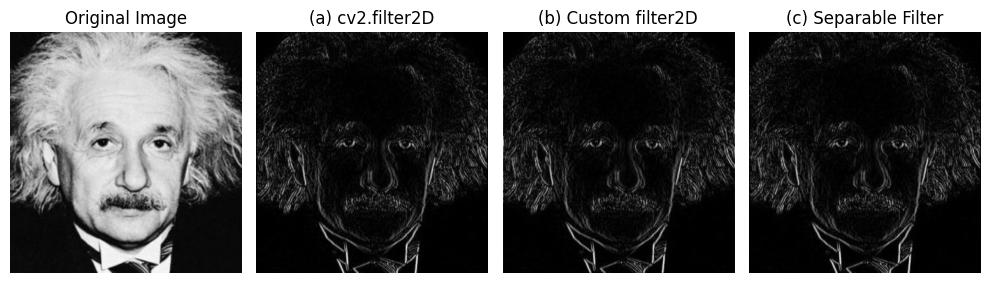

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/q7.jpeg', cv2.IMREAD_GRAYSCALE) # Update filename if needed
img_float = img.astype(np.float32)

kernel_2d = np.array([[1, 0, -1], 
                      [2, 0, -2], 
                      [1, 0, -1]], dtype=np.float32)

# (a) Using cv2.filter2D
res_a = cv2.filter2D(img_float, -1, kernel_2d)

# (b) Custom implementation
def custom_filter2d(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
    return output

res_b = custom_filter2d(img_float, kernel_2d)

# (c) Using separability
col_vec = np.array([[1], [2], [1]], dtype=np.float32)
row_vec = np.array([[1, 0, -1]], dtype=np.float32)

res_c_step1 = cv2.filter2D(img_float, -1, row_vec)
res_c = cv2.filter2D(res_c_step1, -1, col_vec)

def normalize_display(image_array):
    abs_img = np.abs(image_array)
    return cv2.normalize(abs_img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

fig, axes = plt.subplots(1, 4, figsize=(10, 10))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(normalize_display(res_a), cmap='gray')
axes[1].set_title('(a) cv2.filter2D')
axes[1].axis('off')

axes[2].imshow(normalize_display(res_b), cmap='gray')
axes[2].set_title('(b) Custom filter2D')
axes[2].axis('off')

axes[3].imshow(normalize_display(res_c), cmap='gray')
axes[3].set_title('(c) Separable Filter')
axes[3].axis('off')

plt.tight_layout()
plt.show()


## Question 8: Image Zooming (Interpolation)

We implemented a custom function to scale up a small image by a factor of $s=4$ using two different interpolation methods:

1. **Nearest-Neighbor Interpolation:** Maps new pixels to the nearest integer coordinate in the original image. This is fast but produces blocky, pixelated edges.
2. **Bilinear Interpolation:** Calculates a distance-weighted average of the four closest original pixels. This blends the colors and produces a much smoother image.

**Quantitative Results:** 
To mathematically evaluate accuracy, we compared both zoomed images to the ground-truth, high-resolution original using the **Normalized Sum of Squared Difference (SSD)**. 

The SSD for Bilinear interpolation is noticeably lower than the SSD for Nearest-Neighbor. A lower SSD indicates a smaller margin of error, quantitatively proving that bilinear interpolation is far better at estimating and reconstructing missing pixel data.


Normalized SSD (Nearest Neighbor): 0.0096
Normalized SSD (Bilinear): 0.0077


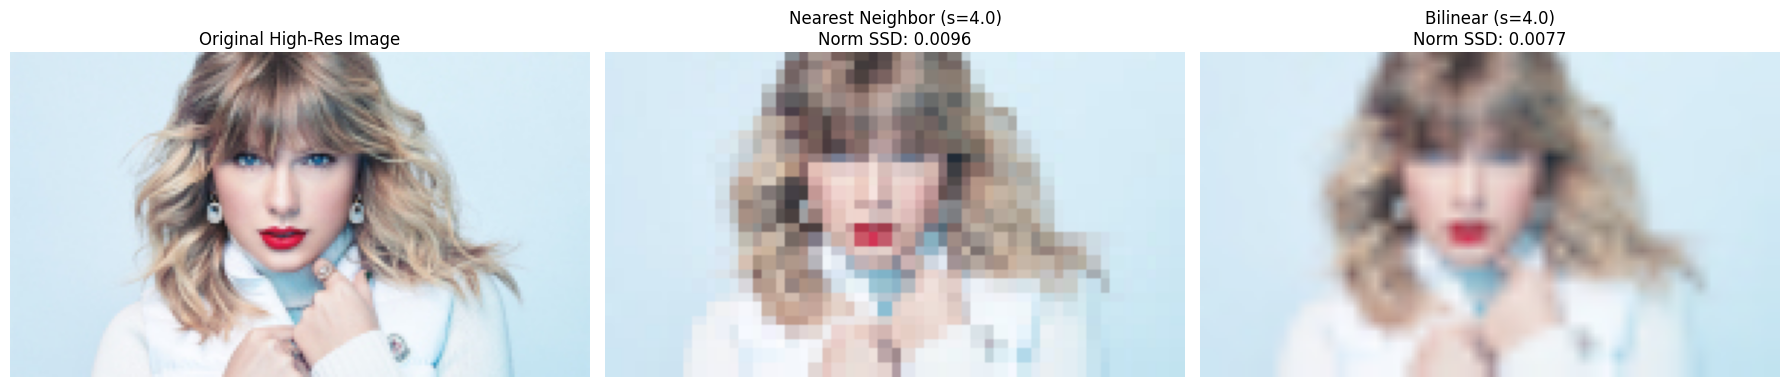

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def zoom_image(image, s, method='nearest'):
    h, w = image.shape[:2]
    new_h, new_w = int(h * s), int(w * s)
    
    # Generate a grid of coordinates for the new image
    y_dst, x_dst = np.indices((new_h, new_w))
    
    if method == 'nearest':
        # Map coordinates back and round to nearest integer
        y_src = np.clip(np.round(y_dst / s).astype(int), 0, h - 1)
        x_src = np.clip(np.round(x_dst / s).astype(int), 0, w - 1)
        zoomed = image[y_src, x_src]
        
    elif method == 'bilinear':
        # Map coordinates back (keep as floats)
        y_src = y_dst / s
        x_src = x_dst / s
        
        # Get the 4 surrounding pixels
        y0 = np.clip(np.floor(y_src).astype(int), 0, h - 1)
        y1 = np.clip(np.ceil(y_src).astype(int), 0, h - 1)
        x0 = np.clip(np.floor(x_src).astype(int), 0, w - 1)
        x1 = np.clip(np.ceil(x_src).astype(int), 0, w - 1)
        
        # Calculate distances
        dy = y_src - y0
        dx = x_src - x0
        
        # Expand dims for broadcasting if image is colored (3 channels)
        if len(image.shape) == 3:
            dy = np.expand_dims(dy, axis=2)
            dx = np.expand_dims(dx, axis=2)
            
        I00 = image[y0, x0].astype(np.float32)
        I01 = image[y0, x1].astype(np.float32)
        I10 = image[y1, x0].astype(np.float32)
        I11 = image[y1, x1].astype(np.float32)
        
        # Weighted average
        zoomed = (I00 * (1 - dy) * (1 - dx) +
                  I01 * (1 - dy) * dx +
                  I10 * dy * (1 - dx) +
                  I11 * dy * dx)
        
        zoomed = np.clip(np.round(zoomed), 0, 255).astype(np.uint8)
        
    return zoomed

def calc_normalized_ssd(img_true, img_zoomed):
    # Ensure dimensions match before comparing (in case of rounding differences)
    min_h = min(img_true.shape[0], img_zoomed.shape[0])
    min_w = min(img_true.shape[1], img_zoomed.shape[1])
    
    i_true = img_true[:min_h, :min_w].astype(np.float32)
    i_zoom = img_zoomed[:min_h, :min_w].astype(np.float32)
    
    ssd = np.sum((i_true - i_zoom) ** 2)
    normalized_ssd = ssd / np.sum(i_true ** 2)
    return normalized_ssd

# Load original large image and small image
img_orig = cv2.imread('images/im04.jpg')  # Change to im02.png etc if needed
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

img_small = cv2.imread('images/im04small.jpg') # Change to im02small.png etc if needed
img_small = cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB)

# Zoom by factor of 4
s = 4.0
zoom_nn = zoom_image(img_small, s, method='nearest')
zoom_bi = zoom_image(img_small, s, method='bilinear')

# Calculate SSD
ssd_nn = calc_normalized_ssd(img_orig, zoom_nn)
ssd_bi = calc_normalized_ssd(img_orig, zoom_bi)

print(f"Normalized SSD (Nearest Neighbor): {ssd_nn:.4f}")
print(f"Normalized SSD (Bilinear): {ssd_bi:.4f}")

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_orig)
axes[0].set_title('Original High-Res Image')
axes[0].axis('off')

axes[1].imshow(zoom_nn)
axes[1].set_title(f'Nearest Neighbor (s={s})\nNorm SSD: {ssd_nn:.4f}')
axes[1].axis('off')

axes[2].imshow(zoom_bi)
axes[2].set_title(f'Bilinear (s={s})\nNorm SSD: {ssd_bi:.4f}')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 9: GrabCut Segmentation and Depth of Field Effect

We use the GrabCut algorithm to segment a flower from its background, then use that mask to artificially create a shallow depth of field (portrait mode) effect.

1. **Segmentation & Enhancement:** We provide a bounding box to `cv2.grabCut` to generate a binary mask that isolates the flower. We use this mask to separate the sharp foreground from the background (where the flower pixels are set to black/0). We then apply a strong Gaussian blur to the isolated background and composite the sharp flower directly back on top.
2. **(c) The Dark Halo Artifact:** The background just beyond the edge of the flower appears unnaturally dark. This happens because in the isolated background, the flower area is pure black ($0$). When the Gaussian blur is applied, it averages and "bleeds" these black pixels outward into the surrounding green background. When the sharp flower is placed back on top, this darkened boundary remains visible just outside the petals as a dark halo.


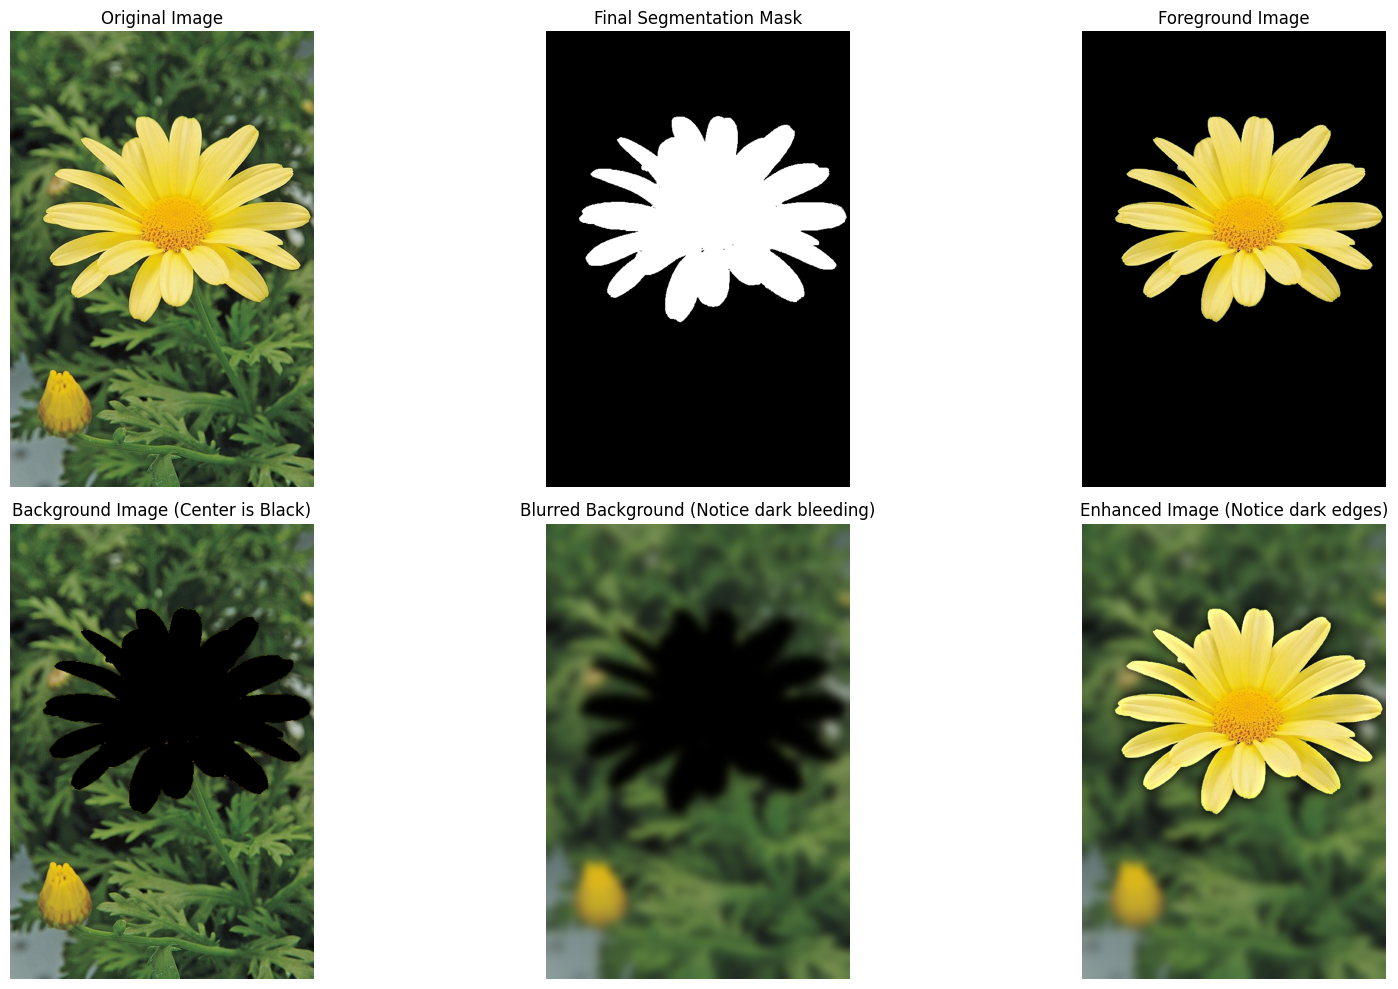

In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (Update filename to your actual flower image)
img = cv2.imread('images/q9.jpeg') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# (a) GrabCut Segmentation
mask = np.zeros(img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define bounding box (x, y, w, h). 
# IMPORTANT: Adjust these values so the rectangle tightly fits around the flower
h, w = img.shape[:2]
rect = (60, 60, w - 60, h - 250) 

cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Modify mask: 0 and 2 are background, 1 and 3 are foreground
mask_binary = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
mask_bg_binary = 1 - mask_binary

# Extract Foreground and Background
img_fg = img_rgb * mask_binary[:, :, np.newaxis]
img_bg = img_rgb * mask_bg_binary[:, :, np.newaxis]

# (b) Produce Enhanced Image
# Apply Gaussian Blur to the extracted background
# The large kernel (55x55) creates a strong blur
img_bg_blurred = cv2.GaussianBlur(img_bg, (55, 55), 0)

# Combine sharp foreground with blurred background
enhanced_img = cv2.add(img_fg, img_bg_blurred)

# Display Results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_binary, cmap='gray')
axes[0, 1].set_title('Final Segmentation Mask')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_fg)
axes[0, 2].set_title('Foreground Image')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_bg)
axes[1, 0].set_title('Background Image (Center is Black)')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_bg_blurred)
axes[1, 1].set_title('Blurred Background (Notice dark bleeding)')
axes[1, 1].axis('off')

axes[1, 2].imshow(enhanced_img)
axes[1, 2].set_title('Enhanced Image (Notice dark edges)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## Question 10: Edge-Preserving Smoothing with Bilateral Filter

We implement a bilateral filter to smoothen an image to remove noise and texture while strictly preserving sharp edges.

1. **The Concept:** Unlike a standard Gaussian blur that averages pixels based only on spatial distance, a bilateral filter also weighs pixels based on *color similarity*. If a window spans across a sharp edge, the vastly different colors on the other side receive a near-zero weight and are excluded from the blur. This keeps the edge perfectly sharp.
2. **Implementation:** We compare OpenCV's `cv2.bilateralFilter` against a standard `cv2.GaussianBlur` to demonstrate this effect visually. We then implement a custom bilateral filter from scratch, manually computing the spatial and color weights for each pixel neighborhood.
3. **Results:** Visually, both bilateral filters smoothen the flat textures (sky/water) while keeping the mountain edges razor-sharp, unlike the Gaussian blur which softens everything. Quantitatively, the Mean Squared Error (MSE) between the OpenCV filter and our custom implementation is extremely low, mathematically proving our algorithm accurately replicates the function.


Running custom bilateral filter... Please wait.
Mean Squared Error (MSE) between OpenCV and Custom Bilateral Filter: 28.9092


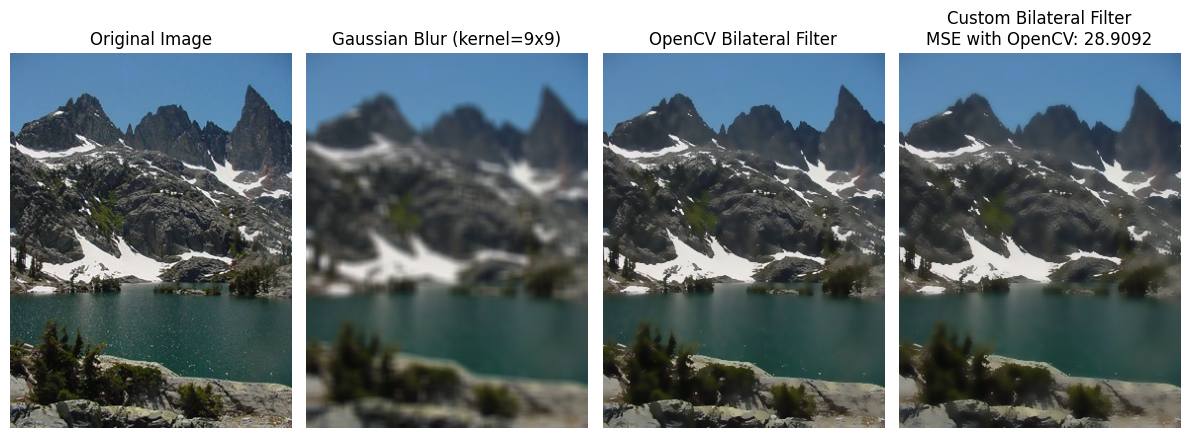

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_bilateral_filter(img, d, sigma_s, sigma_r):
    # Padding size based on kernel diameter
    radius = d // 2
    # Pad image to handle borders
    img_pad = cv2.copyMakeBorder(img, radius, radius, radius, radius, cv2.BORDER_REFLECT).astype(np.float32)
    output = np.zeros_like(img, dtype=np.float32)
    
    # Precompute the spatial Gaussian weights (constant for all windows)
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_w = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    
    # Slide window over the image
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Extract local window and center pixel
            window = img_pad[i:i+d, j:j+d, :]
            center_val = img_pad[i+radius, j+radius, :]
            
            # Calculate range weight based on color difference (Euclidean distance squared)
            color_diff_sq = np.sum((window - center_val)**2, axis=2)
            range_w = np.exp(-color_diff_sq / (2 * sigma_r**2))
            
            # Combine weights and normalize
            weights = spatial_w * range_w
            weights_sum = np.sum(weights)
            
            # Apply weights to each color channel
            for c in range(3):
                output[i, j, c] = np.sum(window[:, :, c] * weights) / weights_sum
                
    return output.astype(np.uint8)

def calculate_mse(img1, img2):
    return np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)


# Load Image (Update filename as needed)
img = cv2.imread('images/q10.jpeg') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Parameters
d = 9          # Diameter of pixel neighborhood
sigma_s = 75   # Spatial sigma (larger = further pixels mix)
sigma_r = 75   # Range sigma (larger = less strict on color similarity)

# 1. OpenCV Gaussian Blur (for baseline comparison)
img_gaussian = cv2.GaussianBlur(img_rgb, (d, d), sigma_s)

# 2. OpenCV Bilateral Filter
img_cv2_bilateral = cv2.bilateralFilter(img_rgb, d, sigma_r, sigma_s)

# 3. Custom Bilateral Filter (This will take a few seconds to run)
print("Running custom bilateral filter... Please wait.")
img_custom_bilateral = custom_bilateral_filter(img_rgb, d, sigma_s, sigma_r)

# 4. Quantitative Comparison
mse_value = calculate_mse(img_cv2_bilateral, img_custom_bilateral)
print(f"Mean Squared Error (MSE) between OpenCV and Custom Bilateral Filter: {mse_value:.4f}")

# Display Results
fig, axes = plt.subplots(1, 4, figsize=(12, 8))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_gaussian)
axes[1].set_title(f'Gaussian Blur (kernel={d}x{d})')
axes[1].axis('off')

axes[2].imshow(img_cv2_bilateral)
axes[2].set_title('OpenCV Bilateral Filter')
axes[2].axis('off')

axes[3].imshow(img_custom_bilateral)
axes[3].set_title(f'Custom Bilateral Filter\nMSE with OpenCV: {mse_value:.4f}')
axes[3].axis('off')

plt.tight_layout()
plt.show()
